In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

First, we'll define a very simple custom function that we'll try to fit with a simple model. I chose a quadratic function, but it's worth coming back to this later and trying something more interesting, such as a transcendental function.

In [2]:
def qfunction(x: float) -> float:
    return 0.14 * x**2 - 0.57 * x + 1.2

Let's just see what this function looks like briefly.

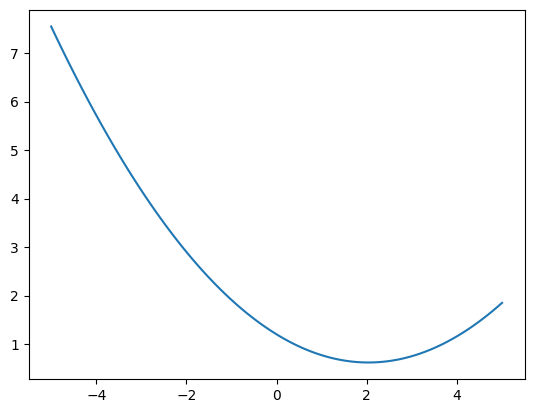

In [3]:
xs = torch.linspace(-5, 5, 100)
ys = qfunction(xs)
plt.plot(xs, ys)

Define a simple model that will try to fit our function. This model is simply Linear -> ReLU -> Linear.

In [4]:
class MyNn(nn.Module):
    def __init__(self, features: int):
        super().__init__()
        self.lin1 = nn.Linear(1, features, bias=True)
        self.lin2 = nn.Linear(features, 1, bias=True)

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x
        

Final loss of 0.21270421147346497


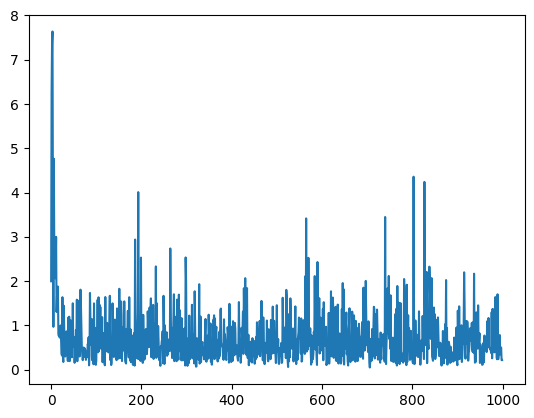

In [5]:
# Features defines how "big" the network is, that is, how many internal weights it can leverage.
model = MyNn(features = 64)

# Here we create a Stochastic Gradient Descent optimizer to optimize our neural network.
# Learning rate affects how much the optimizer steps the weights on each iteration.
optimizer = torch.optim.SGD(model.parameters(), lr=0.25)

# L1 Loss is calculated as the mean of the absolute difference between the prediction and label.
# So simply, l1loss = mean(|label - pred|)
lossfn = nn.L1Loss()

# We define a batchsize of 8. An entire batch of samples is run through the model on each iteration.
batchsize = 8

# We'll train by sampling our custom function 1000 times between -5 and 5.
s_num = []
losses = []
for x in range(1000):
    optimizer.zero_grad()

    # rand returns between 0 and 1, so the shift and scale
    # sets the range to be between -5 and 5.
    input = (torch.rand(batchsize, 1) - 0.5) * 10
    label = qfunction(input)

    pred = model(input)
    loss = lossfn(label, pred)
    loss.backward()
    optimizer.step()

    s_num.append(x)
    losses.append(loss.item())
    
print("Final loss of {}".format(loss))
plt.plot(s_num, losses)

torch.Size([100, 1])


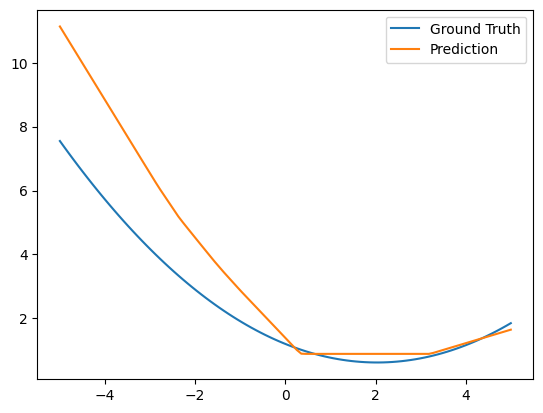

In [6]:
model.eval()
with torch.no_grad():
    ps = model(xs.unsqueeze(-1))
    print(ps.shape)

plt.plot(xs, ys, label='Ground Truth')
plt.plot(xs, ps.flatten(), label='Prediction')
plt.legend()

Key topics from this notebook
* Linear Layers
* Activation functions such as ReLU
* Optimizers like Stochastic Gradient Descent
* Loss functions like L1 Loss
* "Hyper Parameters"
  * Batchsize
  * Learning Rate

As homework...
* The default configuration doesn't fit the function terribly well. Try altering the model and training parameters to fit the data better without blowing up the time it takes to train.
  * To accomplish this, you can change the learning rate, linear layers' feature size, batchsize, number of samples to train on, or even the optimizer type and loss function.
* Replace the quadratic function with one of your own, and try to fit both functions with the same hyperparameters. Was your function "harder" or "easier" than the quadratic function?